<a href="https://colab.research.google.com/github/gyeongee/TIL/blob/main/pca_%EC%8B%A0%EC%9A%A9%EC%B9%B4%EB%93%9C%EA%B3%A0%EA%B0%9D%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%84%B8%ED%8A%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# zip 파일 압축 해제
import zipfile

with zipfile.ZipFile('/content/pca_credict_card.zip','r') as zip_ref:
  zip_ref.extractall('data')

In [11]:
# 첫번째 행을 컬럼명으로 사용
data=pd.read_excel('/content/data/default of credit card clients.xls',header=1)
data.head(3)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [13]:
df = data.drop('ID',axis=1)
df.head(3)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_A

In [15]:
df.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


'default payment next month' 컬럼이 target 값으로 '다음달 연체 여부'를 의미하며 '연체'일 경우 1, '정상납부'가 0 입니다.

In [16]:
y_target=df['default payment next month']
X_features=df.drop('default payment next month',axis=1)

<Axes: >

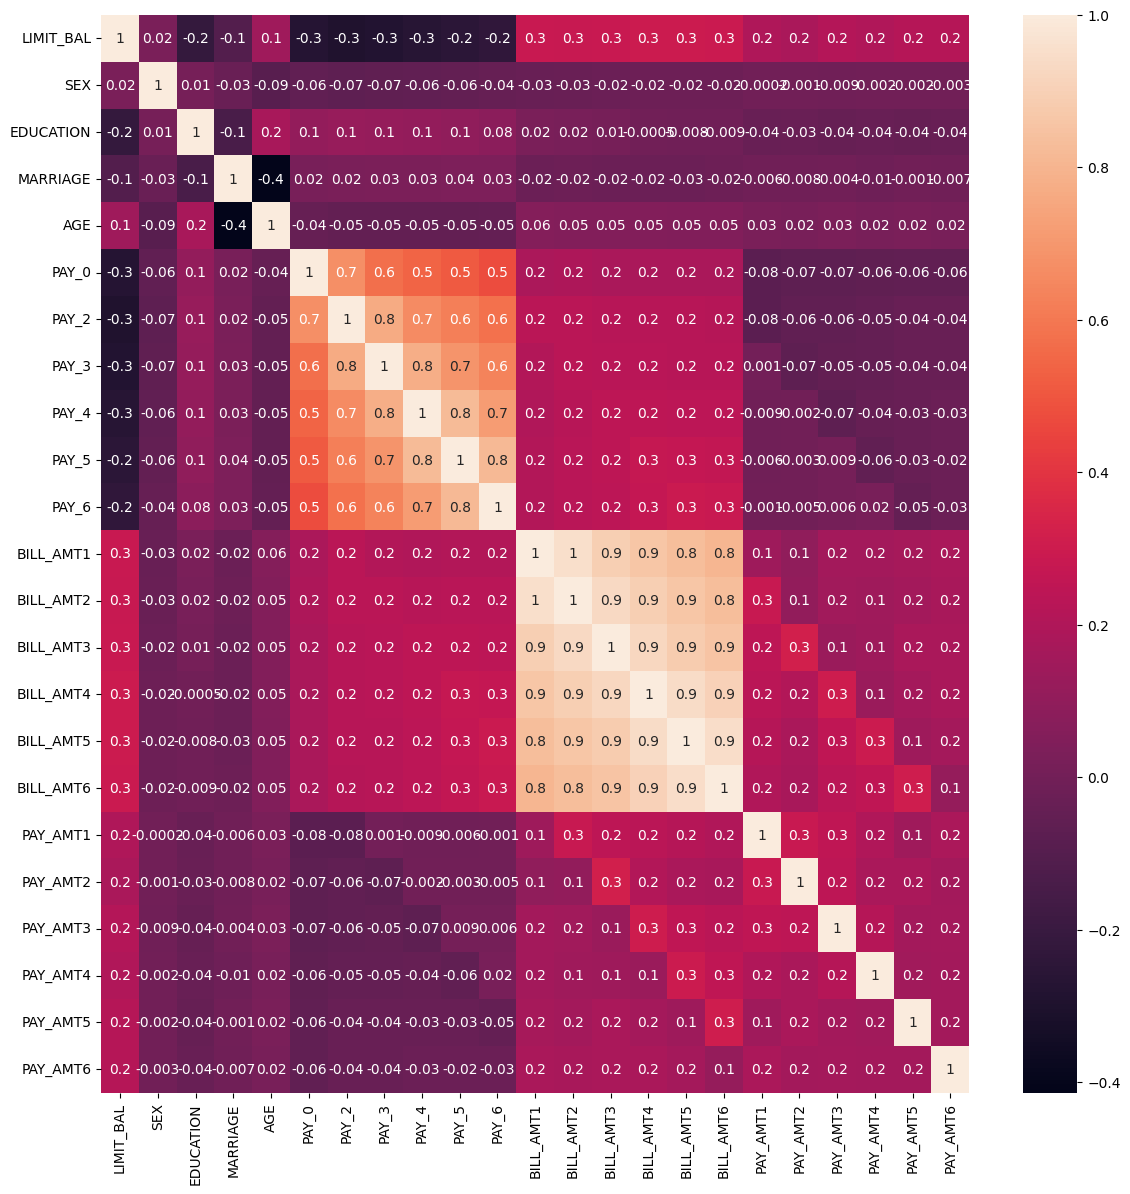

In [17]:
# 상관도 분석
# heatmap 안에 표시되는 숫자의 형식(format)을 지정하는 파라미터
corr = X_features.corr()
plt.figure(figsize=(14,14))
sns.heatmap(corr,annot=True,fmt='.1g')

BILL_AMT1~BILL_AMT6 6개의 속성끼릐 상관도가 대부분 0.9 이상으로 매우 높음을 알 수 있습니다. 이보다는 낮지만 PAY_1~PAY6까지의 속성 역시 상관도가 높습니다.

이렇게 높은 상관도를 가진 속성들은 소수의 PCA만으로도 자연스럽게 이 속성들의 변동성을 수용할 수 있습니다.

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#BILL_AMT1 ~ BILL_AMT6까지의 6개의 속성명 생성
cols_bill = ['BILL_AMT'+str(i) for i in range(1,7)]
print(f'대상 속성명:{cols_bill}')

# 2개의 PCA 속성을 가진 PCA 객체 생성하고, explained_variance_ratio_ 계산을 위해 fit() 호출
scaler=StandardScaler()
df_cols_scaled = scaler.fit_transform(X_features[cols_bill])

pca=PCA(n_components=2)
pca.fit(df_cols_scaled)
print(f'PCA Component별 변동성:{pca.explained_variance_ratio_}')

대상 속성명:['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
PCA Component별 변동성:[0.90555253 0.0509867 ]


단 2개의 PCA  컴포넌트만으로도 6개의 속성의 변동성을 약 95% 이상 설명할 수 있으며

 특히 첫 번쨰 PCA 축으로 90%의 변동성을 수용할 정도로 이 6개의 속성의 상관도가 매우 높습니다.

In [20]:
# 원본 데이터와 PCA 변환 데이터 세트의 분류 예측 결과 상호 비교
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rcf = RandomForestClassifier(n_estimators=300,random_state=156)
scores = cross_val_score(rcf,X_features,y_target,scoring='accuracy',cv=3)

print(f'CV=3 인 경우의 개별 Fold 세트별 정확도:{scores}')
print(f'평균 정확도:{np.mean(scores):.4f}')

CV=3 인 경우의 개별 Fold 세트별 정확도:[0.8083 0.8196 0.8232]
평균 정확도:0.8170


In [24]:
#  원본 데이터 세트에 먼저 StandardScaler 적용
scaler = StandardScaler()
df_scaled=scaler.fit_transform(X_features)

pca=PCA()
pca.fit_transform(df_scaled)
print(pca.explained_variance_ratio_)

[0.28448215 0.17818817 0.06743307 0.06401154 0.04457556 0.04161737
 0.03946035 0.03859201 0.03788041 0.03404042 0.03186036 0.02968788
 0.02482385 0.02279956 0.01754959 0.01129943 0.01083167 0.00820396
 0.00572984 0.00305025 0.00177324 0.00109979 0.00100953]


pc가 다섯개일때의 설명력이 63.87% 이고 pc가 15개일 때 약 95%의 설명력을 가집니다.

n_components=5, 8, 10, 12, 15 등을 비교해서 교차검증 성능이 가장 좋은 component 수를 선택해봅시다.

In [29]:
# 2개의 컴포넌트로 PCA 변환한 데이터 세트 예측

#  원본 데이터 세트에 먼저 StandardScaler 적용
scaler = StandardScaler()
df_scaled=scaler.fit_transform(X_features)

# PCA 변환
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
scores_pca = cross_val_score(rcf,df_pca,y_target,scoring='accuracy',cv=3)

print(f'CV=3 인 경우의 PCA 변환된 개별 Fold 세트별 정확도:{scores_pca}')
print(f'평균 정확도:{np.mean(scores_pca):.4f}')

CV=3 인 경우의 PCA 변환된 개별 Fold 세트별 정확도:[0.7701 0.7818 0.7888]
평균 정확도:0.7802


In [26]:
# 5개의 컴포넌트로 PCA 변환한 데이터 세트 예측

#  원본 데이터 세트에 먼저 StandardScaler 적용
scaler = StandardScaler()
df_scaled=scaler.fit_transform(X_features)

# PCA 변환
pca = PCA(n_components=5)
df_pca = pca.fit_transform(df_scaled)
scores_pca = cross_val_score(rcf,df_pca,y_target,scoring='accuracy',cv=3)

print(f'CV=3 인 경우의 PCA 변환된 개별 Fold 세트별 정확도:{scores_pca}')
print(f'평균 정확도:{np.mean(scores_pca):.4f}')

CV=3 인 경우의 PCA 변환된 개별 Fold 세트별 정확도:[0.788  0.7998 0.8013]
평균 정확도:0.7964


In [27]:
# 8개의 컴포넌트로 PCA 변환한 데이터 세트 예측

#  원본 데이터 세트에 먼저 StandardScaler 적용
scaler = StandardScaler()
df_scaled=scaler.fit_transform(X_features)

# PCA 변환
pca = PCA(n_components=6)
df_pca = pca.fit_transform(df_scaled)
scores_pca = cross_val_score(rcf,df_pca,y_target,scoring='accuracy',cv=3)

print(f'CV=3 인 경우의 PCA 변환된 개별 Fold 세트별 정확도:{scores_pca}')
print(f'평균 정확도:{np.mean(scores_pca):.4f}')

CV=3 인 경우의 PCA 변환된 개별 Fold 세트별 정확도:[0.7912 0.7974 0.802 ]
평균 정확도:0.7969


In [28]:
# 15개의 컴포넌트로 PCA 변환한 데이터 세트 예측

#  원본 데이터 세트에 먼저 StandardScaler 적용
scaler = StandardScaler()
df_scaled=scaler.fit_transform(X_features)

# PCA 변환
pca = PCA(n_components=15)
df_pca = pca.fit_transform(df_scaled)
scores_pca = cross_val_score(rcf,df_pca,y_target,scoring='accuracy',cv=3)

print(f'CV=3 인 경우의 PCA 변환된 개별 Fold 세트별 정확도:{scores_pca}')
print(f'평균 정확도:{np.mean(scores_pca):.4f}')

CV=3 인 경우의 PCA 변환된 개별 Fold 세트별 정확도:[0.8072 0.8147 0.8179]
평균 정확도:0.8133


pc=2 일때 차원을 크게 축소하여 시각화에 유리하지만 원본 정보 중 상당 부분을 버리기 때문에, pc=5로 지정하는 것이 좋습니다.
pc 5와 15의 정확도 차이가 크지 않으므로 pc=5로 지정하겠습니다.

전체 23개 속성의 약 1/4 수준인 6개의 PCA 컴포넌트만으로도 원본 데이터를 기반으로 한 분류 예측 결과보다 약 1~2% 정도의 예측 성능 저하만 발생했습니다.  전체 속성의 1/4 정도만으로도 이 정도 수치의 예측 성능을 유지할 수 있다는 것은 PCA의 뛰어난 압축 능력을 잘 보여주는 것이라고 생각됩니다.